# 8 · Scratch CNN SVDD

**Motivation:** The original Deep SVDD paper (Ruff et al., 2018) trained a LeNet-style network **from scratch** — no pretrained weights, no BatchNorm — specifically to avoid two collapse risks:
1. Pretrained BatchNorm statistics shift embeddings toward zero-mean
2. Pretrained features create a strong prior that the SVDD loss cannot easily override

All previous notebooks used ImageNet-pretrained ResNet-18, which improves feature quality but deviates from the paper's design. This notebook directly tests the paper's philosophy using a modern CNN architecture (deeper than LeNet but still trained from scratch).

**Three variants:**

| Variant | BN | Pretrained | Notes |
|---|---|---|---|
| A — Scratch + BN | Yes | No | Practical, faster convergence |
| B — Scratch, no BN | No | No | Paper-faithful, uses GroupNorm instead |
| C — Pretrained ResNet | Yes | Yes | Reference from notebook 1 |

**Research question:** Does pretrained ResNet help or hurt SVDD for crack detection compared to training from scratch?

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

from src.dataset import load_splits, CrackDataset
from src.train_utils import eval_scores, calibrate_threshold, compute_metrics, print_metrics
from src.viz_utils import plot_score_histogram, plot_roc_curve, plot_confusion_matrix


SPLITS_DIR   = 'splits'
CKPT_DIR     = 'checkpoints'
RESULTS_DIR  = 'results'
os.makedirs(CKPT_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

EMBED_DIM    = 128
LR           = 1e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 64
MAX_EPOCHS   = 50
PATIENCE     = 7
RANDOM_STATE = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

Device : cuda


In [2]:
train_records, val_records, test_records = load_splits(SPLITS_DIR)

train_ds = CrackDataset(train_records, preprocessing='none', augment=False, normal_only=True)
val_ds   = CrackDataset(val_records,   preprocessing='none')
test_ds  = CrackDataset(test_records,  preprocessing='none')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_labels = np.array([r['label'] for r in test_records])

print(f'Train (normal) : {len(train_ds):,}')
print(f'Val            : {len(val_ds):,}')
print(f'Test           : {len(test_ds):,}')

Train (normal) : 15,207
Val            : 3,650
Test           : 3,651


### 3. Scratch CNN Encoder

Modern CNN deeper than LeNet but trained from scratch on crack images.

**Variant A** uses BatchNorm for stable training.  
**Variant B** removes BN entirely (paper-faithful) — uses GroupNorm as a stable alternative that does not shift per-batch statistics toward zero-mean.

In [ ]:
class ScratchCNNSVDD(nn.Module):
    """Modern CNN trained from scratch for Deep SVDD.

    Architecture: 4 conv blocks → AdaptiveAvgPool → Linear projection.
    bias=False throughout — prevents the weights→0, bias→c collapse shortcut.
    use_bn controls BatchNorm vs GroupNorm.
    """
    def __init__(self, embed_dim: int = EMBED_DIM, use_bn: bool = True):
        super().__init__()

        def norm(channels):
            return nn.BatchNorm2d(channels) if use_bn else nn.GroupNorm(8, channels)

        self.encoder = nn.Sequential(
            # Block 1: 256×256 → 128×128
            nn.Conv2d(3,   32,  3, padding=1, bias=False),
            norm(32), nn.ReLU(inplace=True),
            nn.Conv2d(32,  32,  3, padding=1, bias=False),
            norm(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 128×128 → 64×64
            nn.Conv2d(32,  64,  3, padding=1, bias=False),
            norm(64), nn.ReLU(inplace=True),
            nn.Conv2d(64,  64,  3, padding=1, bias=False),
            norm(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 64×64 → 32×32
            nn.Conv2d(64,  128, 3, padding=1, bias=False),
            norm(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            norm(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4: 32×32 → 16×16
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            norm(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            norm(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.head   = nn.Linear(256, embed_dim, bias=False)
        self.centre = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encoder(x))

    def anomaly_score(self, x: torch.Tensor) -> torch.Tensor:
        z = self(x)
        return ((z - self.centre) ** 2).sum(dim=1)

    def init_centre(self, loader: DataLoader, device: torch.device,
                    eps: float = 0.1):
        self.eval()
        zs = []
        with torch.no_grad():
            for x, _ in loader:
                zs.append(self(x.to(device)))
        c = torch.cat(zs, dim=0).mean(dim=0)
        c[(c.abs() < eps) & (c >= 0)] =  eps
        c[(c.abs() < eps) & (c <  0)] = -eps
        self.centre = c.detach()
        print(f'  Centre norm : {self.centre.norm().item():.4f}')


# Quick param count
for name, use_bn in [('Variant A (BN)', True), ('Variant B (no BN)', False)]:
    m = ScratchCNNSVDD(use_bn=use_bn)
    n = sum(p.numel() for p in m.parameters())
    print(f'{name}: {n:,} parameters')

Variant A (BN): 1,205,984 parameters
Variant B (no BN): 1,205,984 parameters


### 4. Training Helper

In [ ]:
class EarlyStopping:
    def __init__(self, patience, ckpt_path):
        self.patience   = patience
        self.ckpt_path  = ckpt_path
        self.best_auroc = 0.0
        self.counter    = 0

    def step(self, auroc, model):
        if auroc > self.best_auroc:
            self.best_auroc = auroc
            self.counter    = 0
            torch.save({'model_state': model.state_dict()}, self.ckpt_path)
        else:
            self.counter += 1
        return self.counter >= self.patience

    def summary(self):
        return f'Best val AUROC: {self.best_auroc:.4f}'


def train_scratch_svdd(model, label, ckpt_name):
    model.init_centre(train_loader, DEVICE)
    c = model.centre

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    es        = EarlyStopping(PATIENCE, os.path.join(CKPT_DIR, ckpt_name))

    train_losses, val_aurocs = [], []
    print(f'Training {label} (max {MAX_EPOCHS} epochs, patience={PATIENCE})...')

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        for x, _ in train_loader:
            x    = x.to(DEVICE)
            z    = model(x)
            loss = ((z - c) ** 2).sum(dim=1).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_scores, val_labels = eval_scores(model, val_loader, DEVICE)
        val_auroc = float(roc_auc_score(val_labels, val_scores))
        val_aurocs.append(val_auroc)

        marker = ' ★' if val_auroc >= es.best_auroc else ''
        if epoch % 5 == 0 or epoch == 1 or marker:
            print(f'  Epoch {epoch:3d}  loss={avg_loss:.5f}  val_AUROC={val_auroc:.4f}{marker}')

        if es.step(val_auroc, model):
            print(f'  Early stop at epoch {epoch}.')
            break

    print(es.summary())
    return train_losses, val_aurocs


print('Helpers defined.')

Helpers defined.


### 5. Train Variant A — Scratch CNN with BatchNorm

In [13]:
model_a = ScratchCNNSVDD(embed_dim=EMBED_DIM, use_bn=True).to(DEVICE)
losses_a, aurocs_a = train_scratch_svdd(
    model_a, 'Variant A (Scratch + BN)', 'scratch_bn_best.pt'
)

  Centre norm : 1.1314
Training Variant A (Scratch + BN) (max 50 epochs, patience=7)...
  Epoch   1  loss=1.08653  val_AUROC=0.6281 ★
  Epoch   2  loss=0.02259  val_AUROC=0.6519 ★
  Epoch   4  loss=0.01222  val_AUROC=0.6608 ★
  Epoch   5  loss=0.00954  val_AUROC=0.6667 ★
  Epoch   6  loss=0.00773  val_AUROC=0.6678 ★
  Epoch   8  loss=0.00493  val_AUROC=0.6685 ★
  Epoch  10  loss=0.00364  val_AUROC=0.6637
  Epoch  15  loss=0.00214  val_AUROC=0.6249
  Early stop at epoch 15.
Best val AUROC: 0.6685


### 6. Train Variant B — Scratch CNN, No BatchNorm (Paper-Faithful)

In [9]:
model_b = ScratchCNNSVDD(embed_dim=EMBED_DIM, use_bn=False).to(DEVICE)
losses_b, aurocs_b = train_scratch_svdd(
    model_b, 'Variant B (Scratch, no BN)', 'scratch_nobn_best.pt'
)

  Centre norm : 5.9672
Training Variant B (Scratch, no BN) (max 50 epochs, patience=7)...
  Epoch   1  loss=0.07009  val_AUROC=0.5272 ★
  Epoch   4  loss=0.00029  val_AUROC=0.5281 ★
  Epoch   5  loss=0.00021  val_AUROC=0.5208
  Epoch   6  loss=0.00016  val_AUROC=0.5401 ★
  Epoch   8  loss=0.00010  val_AUROC=0.5451 ★
  Epoch  10  loss=0.00009  val_AUROC=0.5126
  Epoch  15  loss=0.00015  val_AUROC=0.4668
  Early stop at epoch 15.
Best val AUROC: 0.5451


### 7. Training Curves

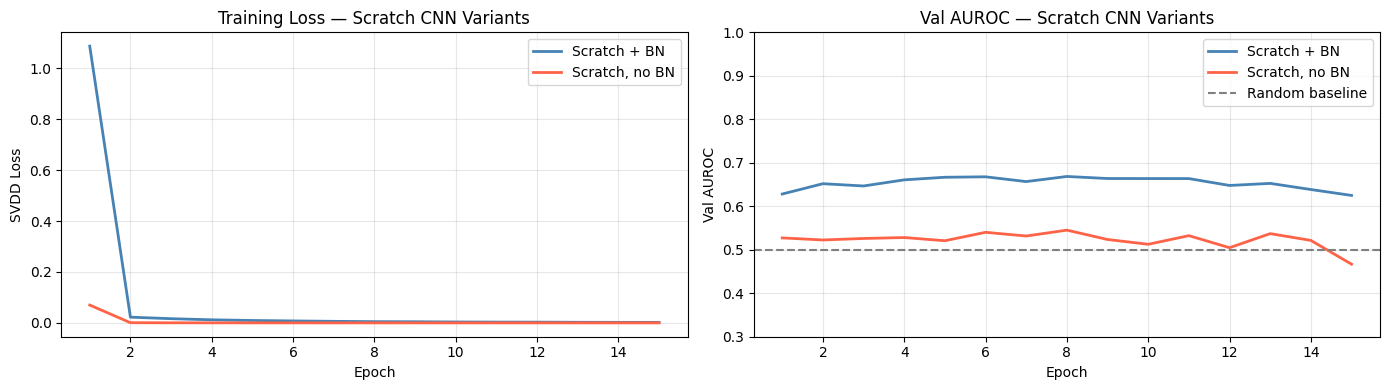

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for losses, aurocs, label, color in [
    (losses_a, aurocs_a, 'Scratch + BN',    'steelblue'),
    (losses_b, aurocs_b, 'Scratch, no BN',  'tomato'),
]:
    epochs = range(1, len(losses) + 1)
    axes[0].plot(epochs, losses, label=label, color=color, lw=2)
    axes[1].plot(epochs, aurocs, label=label, color=color, lw=2)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('SVDD Loss')
axes[0].set_title('Training Loss — Scratch CNN Variants')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].axhline(0.5, color='grey', linestyle='--', label='Random baseline')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val AUROC')
axes[1].set_title('Val AUROC — Scratch CNN Variants')
axes[1].set_ylim(0.3, 1.0)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/scratch_svdd_curves.png', dpi=120, bbox_inches='tight')
plt.show()

### 8. Test Evaluation

In [15]:
results = {}

for model, name, ckpt_name in [
    (model_a, 'Scratch + BN',   'scratch_bn_best.pt'),
    (model_b, 'Scratch, no BN', 'scratch_nobn_best.pt'),
]:
    ckpt = torch.load(os.path.join(CKPT_DIR, ckpt_name),
                      map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt['model_state'])

    val_scores, val_labels = eval_scores(model, val_loader, DEVICE)
    tau, _                 = calibrate_threshold(val_scores, val_labels)
    test_scores, _         = eval_scores(model, test_loader, DEVICE)
    metrics                = compute_metrics(test_scores, test_labels, tau)
    results[name]          = metrics

    print(f'── {name} ──')
    print_metrics(metrics, name)
    print()

── Scratch + BN ──
[Scratch + BN] AUROC: 0.6533  AUPRC: 0.1584  F1: 0.2741
  Confusion matrix:
    TN=  2335  FP=   925
    FN=   182  TP=   209

── Scratch, no BN ──
[Scratch, no BN] AUROC: 0.5587  AUPRC: 0.1234  F1: 0.2076
  Confusion matrix:
    TN=  1251  FP=  2009
    FN=   113  TP=   278



### 9. Comparison vs Pretrained ResNet SVDD

Pretrained ResNet SVDD AUROC : 0.6413


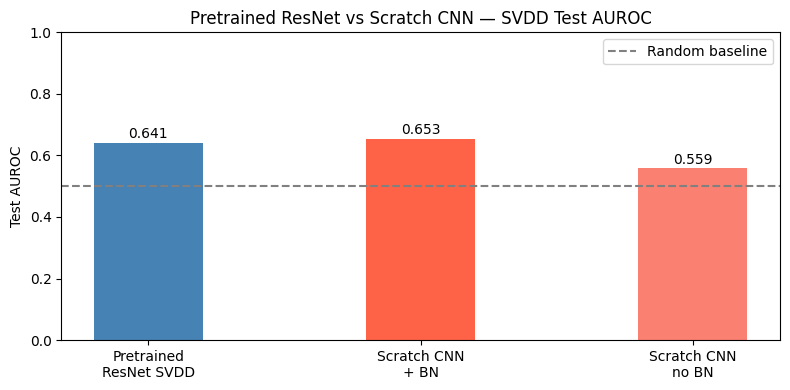


=== Summary ===
  Pretrained ResNet SVDD : 0.6413
  Scratch CNN + BN       : 0.6533
  Scratch CNN no BN      : 0.5587


In [16]:
# Load pretrained ResNet SVDD result from notebook 1
resnet_auroc = None
resnet_path  = f'{RESULTS_DIR}/results_improved_svdd.pkl'
if os.path.exists(resnet_path):
    import pickle
    with open(resnet_path, 'rb') as f:
        saved = pickle.load(f)
    resnet_auroc = saved['svdd']['auroc']
    print(f'Pretrained ResNet SVDD AUROC : {resnet_auroc:.4f}')
else:
    print('Run 1_improved_svdd.ipynb first to get pretrained SVDD results.')
    resnet_auroc = 0.0  # placeholder

# Bar chart
labels_bar = [
    'Pretrained\nResNet SVDD',
    'Scratch CNN\n+ BN',
    'Scratch CNN\nno BN',
]
values  = [
    resnet_auroc,
    results['Scratch + BN']['auroc'],
    results['Scratch, no BN']['auroc'],
]
colours = ['steelblue', 'tomato', 'salmon']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels_bar, values, color=colours, width=0.4)
ax.axhline(0.5, color='grey', linestyle='--', label='Random baseline')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Test AUROC')
ax.set_ylim(0.0, 1.0)
ax.set_title('Pretrained ResNet vs Scratch CNN — SVDD Test AUROC')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/scratch_vs_pretrained.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== Summary ===')
print(f'  Pretrained ResNet SVDD : {resnet_auroc:.4f}')
print(f'  Scratch CNN + BN       : {results["Scratch + BN"]["auroc"]:.4f}')
print(f'  Scratch CNN no BN      : {results["Scratch, no BN"]["auroc"]:.4f}')